In [1]:
import os
import math
import cv2
import numpy as np
import paddle
from paddle import nn
import os
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import time

In [2]:
def one_label_to_probmap(one_label, val_min=0.6):
    dst = cv2.distanceTransform(one_label, cv2.DIST_L2, cv2.DIST_MASK_5)
    dst = (dst-dst.min())/(dst.max()-dst.min())
    mask = dst>0
    dst[mask] = dst[mask]*(1-val_min) + val_min
    return dst

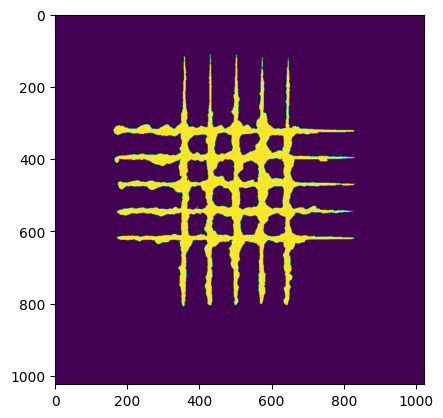

In [25]:
img= Image.open(r'C:\Users\hp\Desktop\fall\all\annotations\9.png')
img = np.array(img)
plt.imshow(img)

In [26]:
mask = img == 1
one_label = mask.astype(np.uint8)

1.0


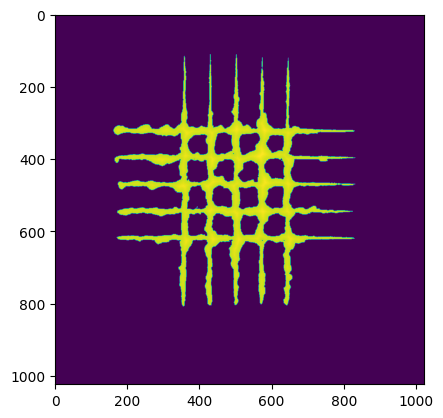

In [27]:
dst = one_label_to_probmap(one_label, 0.9)
print(dst.max())
plt.imshow(dst)

In [6]:
np.count_nonzero(mask) == np.count_nonzero(dst>=0.5)

True

In [37]:
print(np.exp(20)/(np.exp(0) + np.exp(20)))

0.9999999979388464


0.38765192


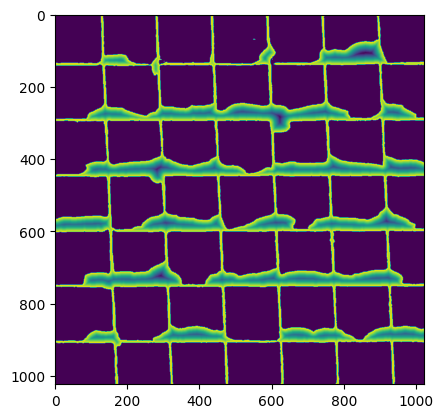

In [7]:
ct = np.zeros(dst.shape, dtype=np.float32)
ct[mask] = 1- dst[mask]
print(ct.max())
plt.imshow(ct)

In [ ]:
img = np.array(Image.open(r"C:\Users\hp\Desktop\2.png"))
img = img*255
plt.imshow(img,cmap='gray')

In [ ]:
#找轮廓并发现最大轮廓
index_tune = 0
contours, hierarchy	= cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
# contours, hierarchy	= cv2.findContours(img2, cv2.RETR_FLOODFILL, cv2.CHAIN_APPROX_NONE)

contours_size = np.array([cv2.contourArea(s) for s in contours ])
sort_index = np.argsort(-contours_size) #返回从大到小的索引,降序排列
idx = sort_index[index_tune] #取一个轮廓，按t增加索引


In [ ]:

def brightness(im, brightness_delta=1):
    im = ImageEnhance.Brightness(im).enhance(brightness_delta)
    return im

def contrast(im, contrast_delta=1):
    im = ImageEnhance.Contrast(im).enhance(contrast_delta)
    return im


def saturation(im, saturation_delta=1):
    im = ImageEnhance.Color(im).enhance(saturation_delta)
    return im


def hue(im, hue_delta):
    im = np.array(im.convert('HSV'))
    im[:, :, 0] = im[:, :, 0] + hue_delta
    im = Image.fromarray(im, mode='HSV').convert('RGB')
    return im


def sharpness(im, sharpness_delta):
    im = ImageEnhance.Sharpness(im).enhance(sharpness_delta)
    return im

In [ ]:
# path = r'C:\Users\hp\Desktop\fall\all1\leftImg8bit\108.jpg'
path = r'C:\Users\hp\Desktop\tc_data\150x70\512x1096\37.jpg'
img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [ ]:
img2 = img.copy()
img_pil2 = Image.fromarray(img2)
# img2 = np.uint8(np.clip((cv2.add(img2,-50)), 0, 255))
# img_pil2 = brightness(img_pil2, 0.5)
# img_pil2 = saturation(img_pil2, 0.5)
# img_pil2 = contrast(img_pil2, 1.5)
img_pil2 = hue(img_pil2, 20.1)
# img_pil2 = sharpness(img_pil2, -10)


img_in = np.array(img_pil2)
img_in = img_in.astype(np.float32)/255.0
img_in = (img_in- img_in.min())/(img_in.max()-img_in.min())
plt.figure(figsize=(18,9))
plt.subplot(1,2,1)
plt.imshow(np.array(img_pil2))
plt.subplot(1,2,2)
plt.imshow(img_in)
